In [1]:
# importing libraries  
import os
import librosa
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout,BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
classes = ['blues','classical','country','disco','hiphop','jazz','metal','pop','reggae','rock']
data = np.load("/content/drive/MyDrive/music_genre_classification/data.npy")
labels = np.load("/content/drive/MyDrive/music_genre_classification/labels.npy")

In [23]:
#splitting data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42, stratify=labels)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# shape = (# samples, time-bins (x), num MFCCs (y))
print(f"X training data shape: {X_train.shape}, y training data shape: {y_train.shape}")
print(f"X validation data shape: {X_val.shape}, y validation data shape: {y_val.shape}")
print(f"X testing data shape: {X_test.shape}, y testing data shape: {y_test.shape}")

X training data shape: (9593, 150, 150, 1), y training data shape: (9593, 10)
X validation data shape: (2399, 150, 150, 1), y validation data shape: (2399, 10)
X testing data shape: (2998, 150, 150, 1), y testing data shape: (2998, 10)


In [10]:
#normalize
X_train = X_train.astype("float32") / 255.0
X_val  = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [11]:
from tensorflow.keras.utils import to_categorical
labels = to_categorical(labels, num_classes=len(classes)) #one-hot encoding the labels
labels
# labels.shape

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [25]:
#build model
model = Sequential()
model.add(Conv2D(filters=32,kernel_size=(3,3),padding='same',activation='relu',input_shape=(150,150,1)))
model.add(BatchNormalization())
model.add(Conv2D(filters=32,kernel_size=(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=3, strides=2,padding='same'))

model.add(Conv2D(filters=64,kernel_size=(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=64,kernel_size=(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=3, strides=2,padding='same'))

model.add(Conv2D(filters=128,kernel_size=(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=128,kernel_size=(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=3, strides=2,padding='same'))

model.add(Dropout(0.3))

model.add(Conv2D(filters=256,kernel_size=(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=256,kernel_size=(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=3, strides=2,padding='same'))

model.add(MaxPooling2D(pool_size=3, strides=2,padding='same'))
model.add(Dropout(0.3))

model.add(Flatten())
model.add(Dense(units=256,activation='relu'))
model.add(Dropout(0.5))

#output layer
model.add(Dense(units=10,activation='softmax'))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 148, 148, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 74, 74, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 74, 74, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 36, 36, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 34, 34, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 17, 17, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 17, 17, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 15, 15, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 256)      │             

 Total params: 2,226,922 (8.50 MB)

 Trainable params: 2,225,002 (8.49 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [31]:
#compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [27]:
# Datagen
# datagen = ImageDataGenerator(vertical_flip=True)   falseeeeee
datagen = ImageDataGenerator(horizontal_flip=True)

In [28]:
# Create an early stopping callback
es_cnn = EarlyStopping(monitor='val_loss', patience=20, min_delta=0, restore_best_weights=True) 

In [29]:
print(X_train.shape)  
print(y_train.shape)  

(9593, 150, 150, 1)
(9593, 10)


In [32]:
#train the model
trainning_history = model.fit(datagen.flow(X_train, y_train), validation_data=(X_val, y_val), epochs=150, batch_size=32, verbose=1, callbacks=[es_cnn])

Epoch 1/150
300/300 ━━━━━━━━━━━━━━━━━━━━ 50s 119ms/step - accuracy: 0.2539 - loss: 2.3310 - val_accuracy: 0.4085 - val_loss: 1.6740
Epoch 2/150
300/300 ━━━━━━━━━━━━━━━━━━━━ 26s 88ms/step - accuracy: 0.3927 - loss: 1.7038 - val_accuracy: 0.5311 - val_loss: 1.2869
Epoch 3/150
300/300 ━━━━━━━━━━━━━━━━━━━━ 27s 91ms/step - accuracy: 0.4701 - loss: 1.4811 - val_accuracy: 0.5527 - val_loss: 1.2651
Epoch 4/150
300/300 ━━━━━━━━━━━━━━━━━━━━ 26s 87ms/step - accuracy: 0.5248 - loss: 1.3501 - val_accuracy: 0.6190 - val_loss: 1.1133
Epoch 5/150
300/300 ━━━━━━━━━━━━━━━━━━━━ 26s 87ms/step - accuracy: 0.5711 - loss: 1.2365 - val_accuracy: 0.6707 - val_loss: 0.9524
Epoch 6/150
300/300 ━━━━━━━━━━━━━━━━━━━━ 26s 88ms/step - accuracy: 0.6102 - loss: 1.1331 - val_accuracy: 0.6653 - val_loss: 0.9577
Epoch 7/150
300/300 ━━━━━━━━━━━━━━━━━━━━ 26s 87ms/step - accuracy: 0.6513 - loss: 1.0336 - val_accuracy: 0.6257 - val_loss: 1.1354
Epoch 8/150
300/300 ━━━━━━━━━━━━━━━━━━━━ 26s 87ms/step - accuracy: 0.6795 - loss: 

In [34]:
#save the trained model
# model.save("/content/drive/MyDrive/music_genre_classification/model.keras")
model.save("/content/drive/MyDrive/music_genre_classification/model_v2.keras")

In [35]:
#recording history in json
trainning_history.history
import json
with open('/content/drive/MyDrive/music_genre_classification/training_history.json', 'w') as f:
    json.dump(trainning_history.history, f)
    

In [36]:
trainning_history.history

{'accuracy': [0.25393515825271606,
  0.39268216490745544,
  0.4701344668865204,
  0.5247576236724854,
  0.5711456537246704,
  0.610236644744873,
  0.6513082385063171,
  0.6794537901878357,
  0.7043677568435669,
  0.724173903465271,
  0.7468987703323364,
  0.7596163749694824,
  0.7726467251777649,
  0.7870321869850159,
  0.8040237426757812,
  0.8161159157752991,
  0.8284165263175964,
  0.8392577767372131,
  0.8458250761032104,
  0.8523923754692078,
  0.8631293773651123,
  0.867611825466156,
  0.8727197051048279,
  0.8827269673347473,
  0.8937767148017883,
  0.8928385376930237,
  0.9007609486579895,
  0.9108725190162659,
  0.9093088507652283,
  0.9075367450714111,
  0.9204628467559814,
  0.9275513291358948,
  0.930574357509613,
  0.9327634572982788,
  0.9347440600395203,
  0.9342228770256042,
  0.942770779132843,
  0.9446471333503723,
  0.9473574757575989,
  0.9509016871452332,
  0.947982907295227,
  0.9526738524436951,
  0.956009566783905,
  0.9605962634086609,
  0.956009566783905,
  0.

In [37]:
#load the model
# model = tf.keras.models.load_model("/content/drive/MyDrive/music_genre_classification/model.keras")
model = tf.keras.models.load_model("/content/drive/MyDrive/music_genre_classification/model_v2.keras")
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 148, 148, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 74, 74, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 74, 74, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 36, 36, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 34, 34, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 17, 17, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 17, 17, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 15, 15, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 256)      │             

 Total params: 6,676,928 (25.47 MB)

 Trainable params: 2,225,002 (8.49 MB)

 Non-trainable params: 1,920 (7.50 KB)

 Optimizer params: 4,450,006 (16.98 MB)

In [38]:
#load training history
import json
with open('/content/drive/MyDrive/music_genre_classification/training_history.json', 'r') as f:
    training_history = json.load(f)

In [39]:
training_history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [40]:
#model evaluation
#model evaluation on training set
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
#model evaluation on validation set
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
#model evaluation on testing set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

train_loss, train_acc, val_loss, val_acc

(0.0073632183484733105,
 0.9969769716262817,
 0.14038150012493134,
 0.9637348651885986)

In [41]:
print(f"test loss: {test_loss}, test accuracy: {test_acc}")

test loss: 0.17528687417507172, test accuracy: 0.9603068828582764


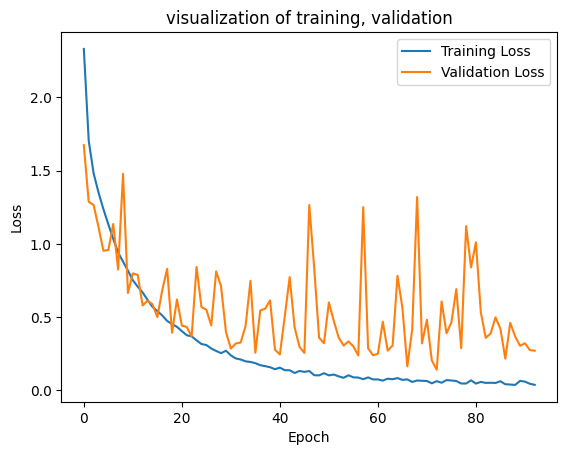

In [47]:
#Visualization of training, validation and testing loss
plt.plot(training_history['loss'], label='Training Loss')
plt.plot(training_history['val_loss'], label='Validation Loss')
# plt.plot(training_history['test_loss'], label='Testing Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('visualization of training, validation')
plt.legend()
plt.show()

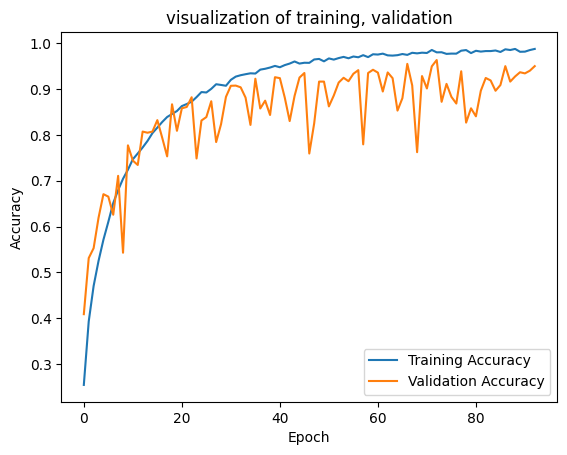

In [49]:
#visualization of training, validation and testing accuracy
plt.plot(training_history['accuracy'], label='Training Accuracy')
plt.plot(training_history['val_accuracy'], label='Validation Accuracy')
# plt.plot(training_history['test_accuracy'], label='Testing Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('visualization of training, validation')
plt.legend()
plt.show()

In [50]:
#make predictions
def make_predictions(X):
    classes = ['blues','classical','country','disco','hiphop','jazz','metal','pop','reggae','rock']
    preds_num=[]
    preds_name=[]
    for X_i in X:
        X_i = X_i[np.newaxis, ...]  # Add batch dimension
        y_pred = model.predict(X_i)
        pred_num = np.argmax(y_pred, axis=1)[0]
        pred_name = classes[pred_num]
        preds_num.append(pred_num)
        preds_name.append(pred_name)
    return preds_num, preds_name

In [51]:
preds_num, preds_name = make_predictions(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━

In [53]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
# #predict on testing set
# y_pred = model.predict(X_test)
# y_pred_classes = np.argmax(y_pred, axis=1)
# y_pred_classes
# confusion matrix
# cm = confusion_matrix(y_test, y_pred_classes)
# print(classification_report(y_test, y_pred_classes, target_names=classes))
# print(cm)

# confusion matrix
y_test_classes = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels to class indices
cm = confusion_matrix(y_test_classes, preds_num)
print(classification_report(y_test_classes, preds_num, target_names=classes))
print(cm)

              precision    recall  f1-score   support

       blues       0.97      0.97      0.97       300
   classical       0.97      0.98      0.97       300
     country       0.97      0.93      0.95       299
       disco       0.95      0.96      0.96       300
      hiphop       1.00      0.97      0.98       300
        jazz       0.95      0.99      0.97       300
       metal       0.97      0.96      0.97       300
         pop       0.97      0.95      0.96       300
      reggae       0.92      0.99      0.96       300
        rock       0.93      0.90      0.92       299

    accuracy                           0.96      2998
   macro avg       0.96      0.96      0.96      2998
weighted avg       0.96      0.96      0.96      2998

[[291   0   2   0   0   2   0   0   4   1]
 [  0 293   0   0   0   6   0   0   0   1]
 [  5   3 278   1   0   3   0   0   6   3]
 [  0   0   0 289   0   0   0   3   5   3]
 [  0   0   0   0 290   0   0   5   4   1]
 [  0   2   0   0   0 297 

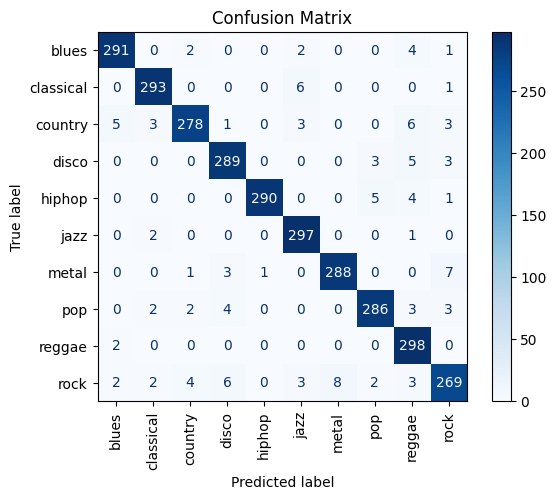

In [55]:
# cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(preds_num))
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
cm_display.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()